In [ ]:
  !pip install kaggle

In [ ]:
!mkdir ~/.kaggle

In [ ]:
!cp "/content/drive/MyDrive/kaggle.json" ~/.kaggle/kaggle.json

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
! kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
100% 149M/149M [00:05<00:00, 41.5MB/s]
100% 149M/149M [00:05<00:00, 28.1MB/s]


In [ ]:
!unzip -q /content/brain-tumor-mri-dataset.zip -d /content/

In [ ]:
!pip install tensorflow

In [ ]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.metrics import roc_curve

from tqdm import tqdm
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Conv2D, MaxPooling2D, LSTM, BatchNormalization, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore")

In [ ]:
train_path ="/content/Training"

In [ ]:
test_path = "/content/Testing"

In [ ]:
classes = sorted(os.listdir(train_path))
classes

['glioma', 'meningioma', 'notumor', 'pituitary']

In [ ]:
def to_frame(path):
    class_types = []
    class_paths = []
    files = os.listdir(path)
    for file in files:
        label_dir = os.path.join(path, file)
        label = os.listdir(label_dir)
        for image in label:
            image_path = os.path.join(label_dir, image)
            class_paths.append(image_path)
            class_name = os.path.splitext(file)[0]
            class_types.append(class_name)
    image_classes = pd.Series(class_types, name='Class')
    image_paths = pd.Series(class_paths, name='Class Path')
    df = pd.concat([image_paths, image_classes], axis=1)
    return df

In [ ]:
train_df = to_frame(train_path)

In [ ]:
test_df = to_frame(test_path)

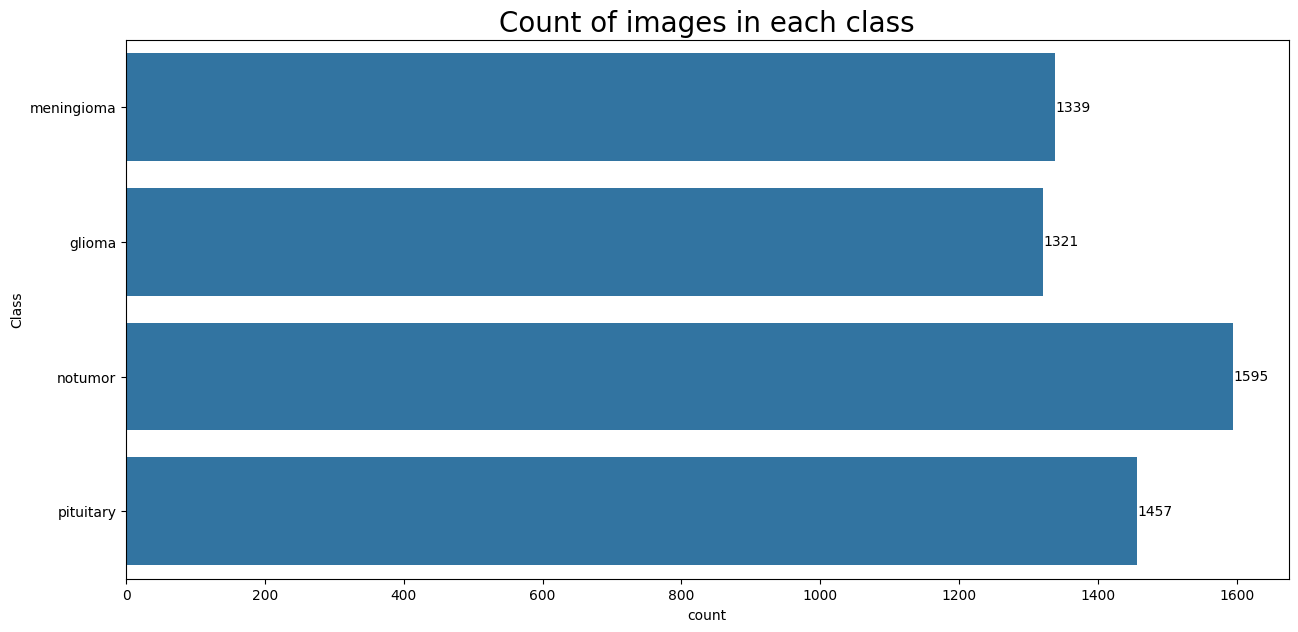

In [ ]:
plt.figure(figsize=(15,7))
ax = sns.countplot(data=train_df , y=train_df['Class'])
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
valid_df, test_df = train_test_split(test_df, train_size=0.5, random_state=20, stratify=test_df['Class'])

In [ ]:
valid_df

,Class Path,Class
592,/content/Testing/glioma/Te-gl_0260.jpg,glioma
18,/content/Testing/meningioma/Te-me_0276.jpg,meningioma
1072,/content/Testing/pituitary/Te-pi_0185.jpg,pituitary
73,/content/Testing/meningioma/Te-me_0179.jpg,meningioma
415,/content/Testing/glioma/Te-gl_0034.jpg,glioma
...,...,...
365,/content/Testing/glioma/Te-gl_0038.jpg,glioma
860,/content/Testing/notumor/Te-no_0385.jpg,notumor
579,/content/Testing/glioma/Te-gl_0175.jpg,glioma
194,/content/Testing/meningioma/Te-me_0221.jpg,meningioma


In [ ]:
batch_size = 32
img_size = (256, 256)

_gen = ImageDataGenerator(rescale=1.0/255, brightness_range=(0.8, 1.2),
                          rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
                          shear_range=0.2, zoom_range=0.2, horizontal_flip=True,
                          fill_mode='nearest')

test_gen = ImageDataGenerator(rescale=1.0/255)

train_gen = _gen.flow_from_dataframe(train_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

test_gen = test_gen.flow_from_dataframe(test_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size, shuffle=False)

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


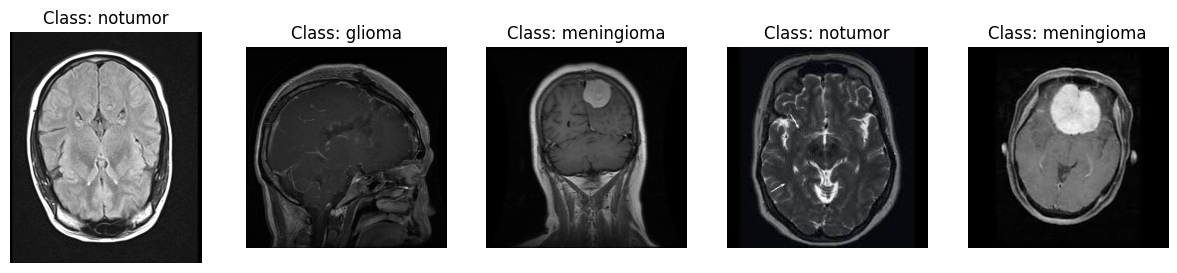

In [ ]:
def display_random_images(df, num_images=5):
    random_indices = random.sample(range(len(df)), num_images)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

    for i, idx in enumerate(random_indices):
        image_path = df.loc[idx, 'Class Path']
        class_name = df.loc[idx, 'Class']

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        axes[i].imshow(image)
        axes[i].set_title(f'Class: {class_name}')
        axes[i].axis('off')
    plt.show()

display_random_images(train_df)

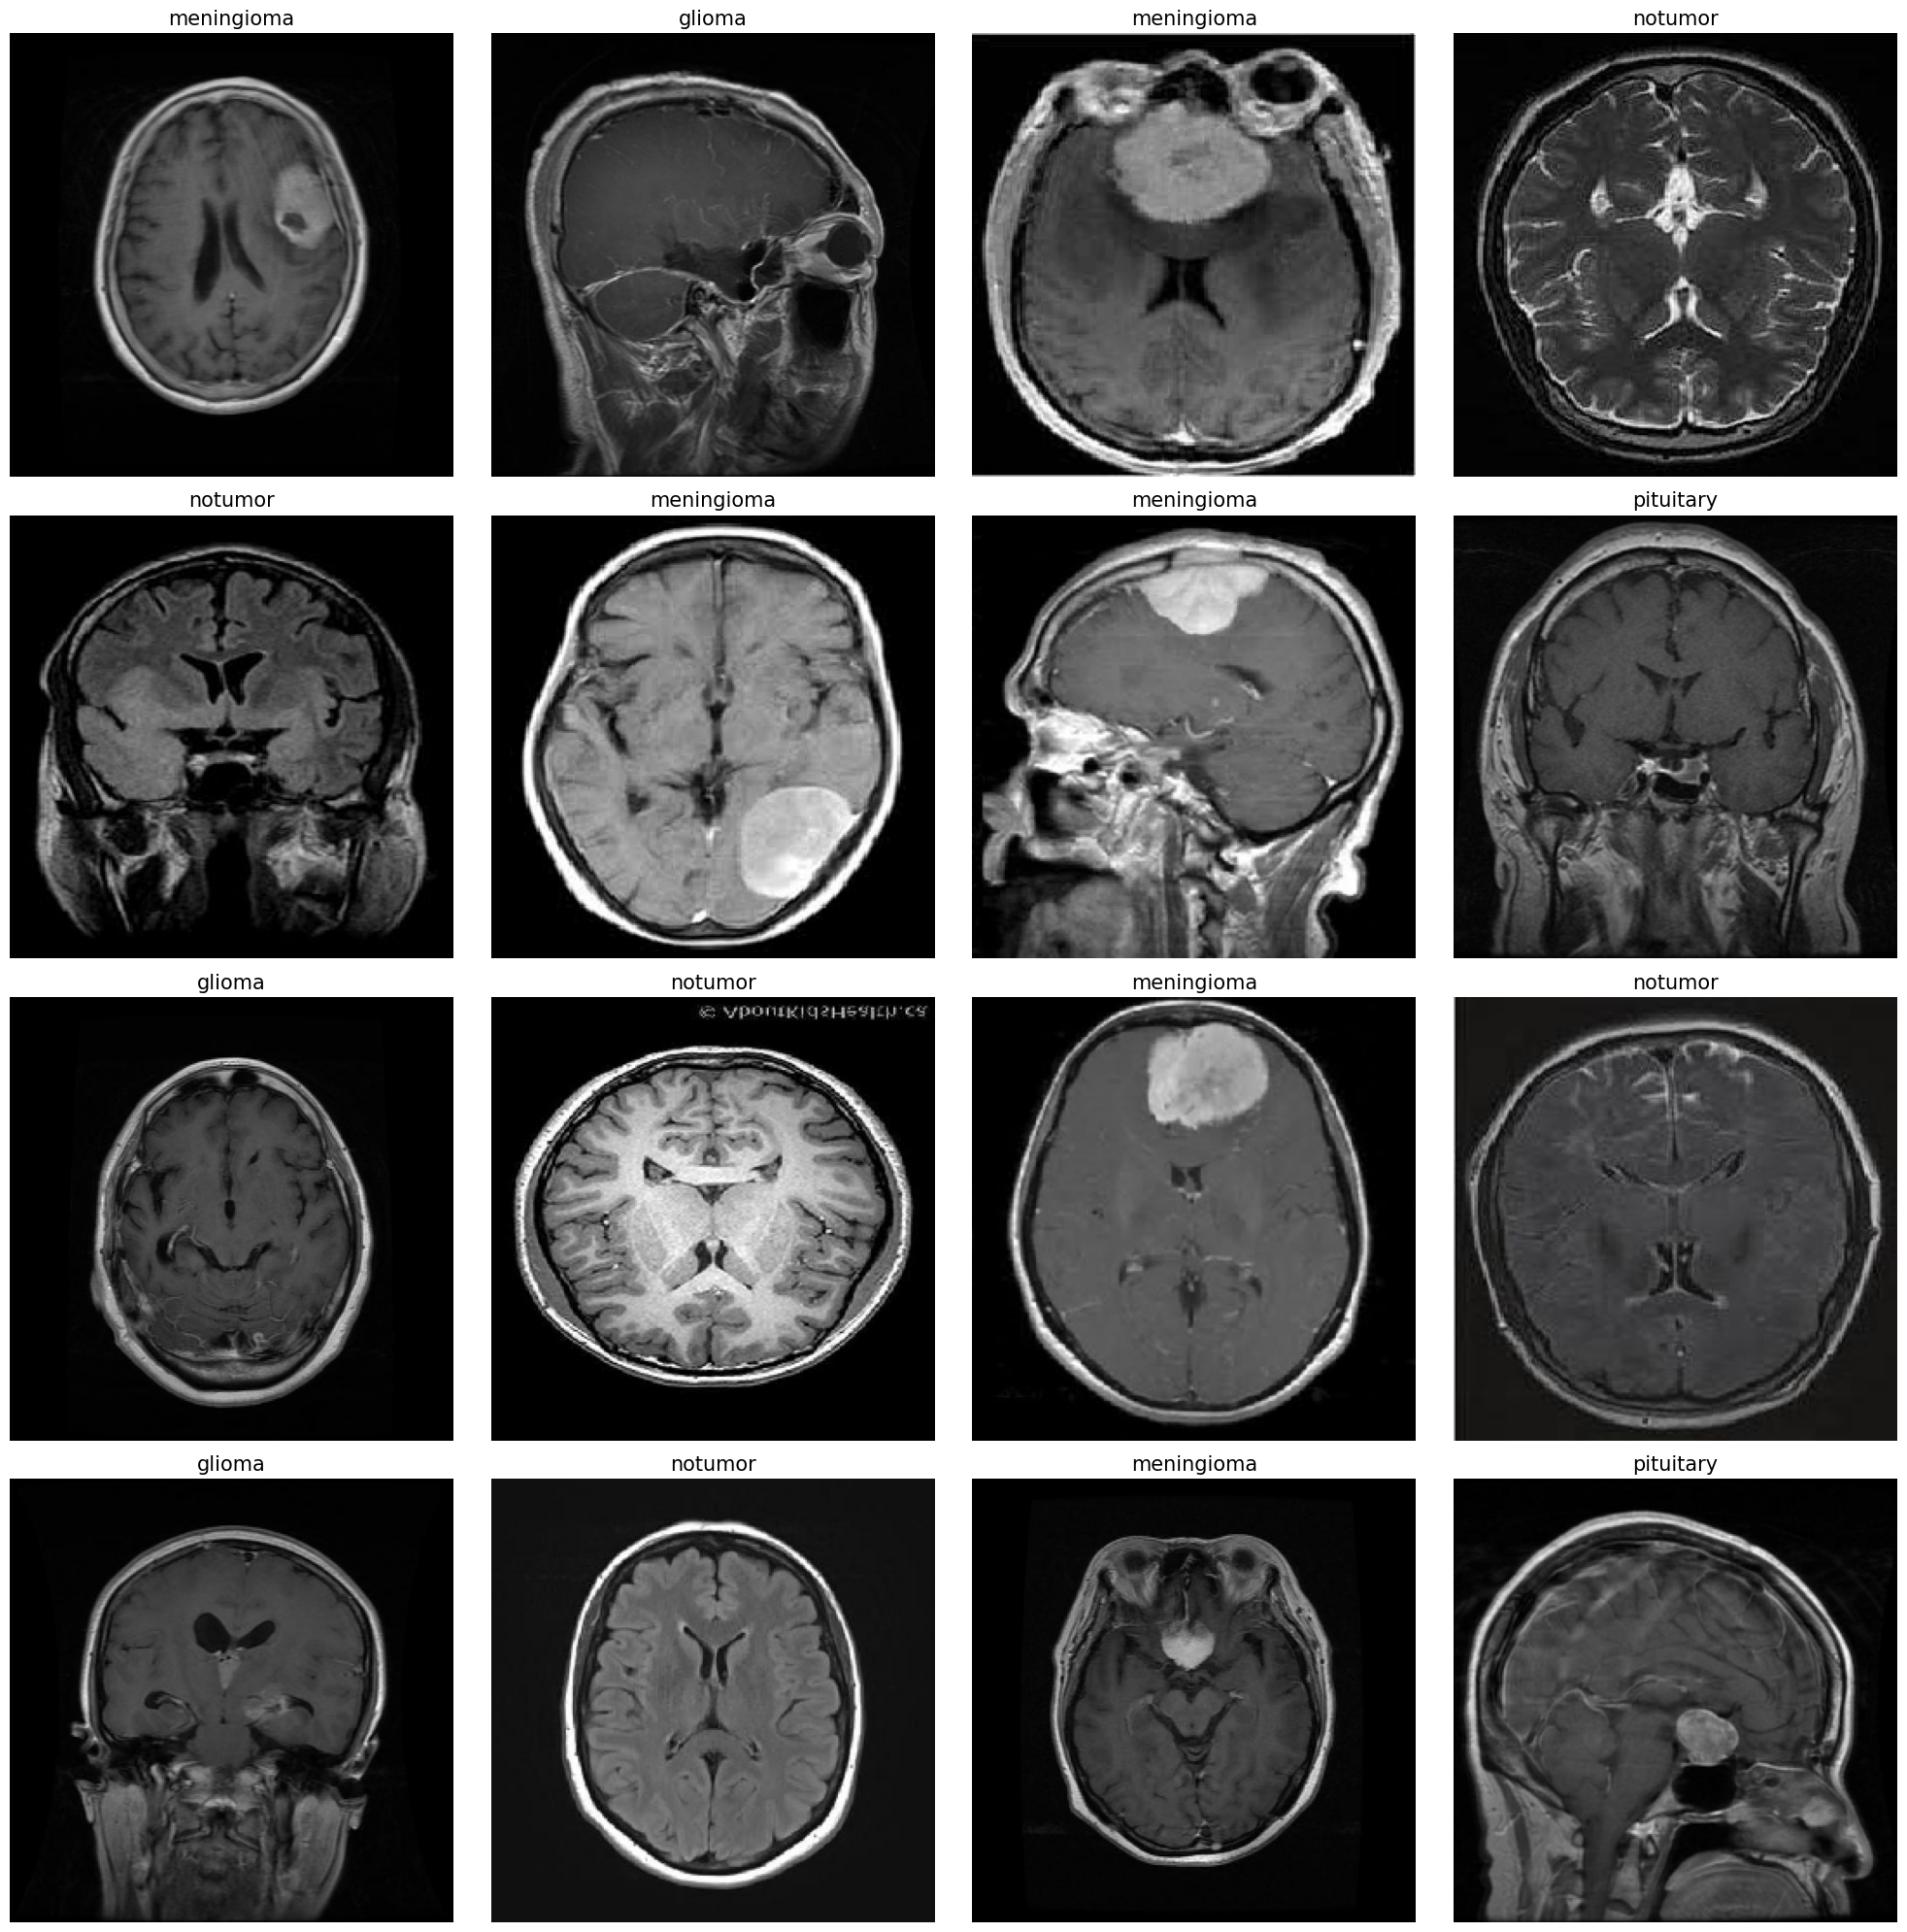

In [ ]:
# class_dict = train_gen.class_indices
# classes = list(class_dict.keys())
# images, labels = next(test_gen)

# plt.figure(figsize=(20, 20))

# for i, (image, label) in enumerate(zip(images, labels)):
#     plt.subplot(4,4, i + 1)
#     plt.imshow(image)
#     class_name = classes[np.argmax(label)]
#     plt.title(class_name, color='k', fontsize=15)

# plt.show()

class_dict = train_gen.class_indices
classes = list(class_dict.keys())

# Get a batch of images and labels from the test generator
images, labels = next(test_gen)

plt.figure(figsize=(20, 20))

# Display a maximum of 16 images
num_images_to_display = min(len(images), 16)

for i in range(num_images_to_display):
    plt.subplot(4, 4, i + 1)  # Create a 4x4 grid of subplots
    plt.imshow(images[i])  # Display the image
    class_name = classes[np.argmax(labels[i])]  # Get the class name for the label
    plt.title(class_name, color='k', fontsize=15)  # Set the title with the class name
    plt.axis('off')  # Hide the axis

plt.tight_layout()  # Adjust subplots to fit into figure area
plt.show()


In [ ]:
img_shape = (256, 256, 3)
base_model = tf.keras.applications.Xception(include_top=False, weights="imagenet", input_shape=img_shape)

model = Sequential([
    base_model,
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Conv2D(16, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Flatten(),
    Dense(512, activation='relu'),

    Dropout(rate=0.3),
    Dense(128, activation='relu'),

    Dropout(rate=0.25),
    Dense(4, activation='softmax')
])

model.compile(Adamax(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy', Precision(), Recall()])
model.summary()

83683744/83683744 [==============================] - 3s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 xception (Functional)       (None, 8, 8, 2048)        20861480  
                                                                 
 conv2d_4 (Conv2D)           (None, 8, 8, 32)          589856    
                                                                 
 max_pooling2d (MaxPooling2  (None, 4, 4, 32)          0         
 D)                                                              
                                                                 
 conv2d_5 (Conv2D)           (None, 4, 4, 32)          9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 2, 2, 32)          0         
 g2D)                                                            
                                                         

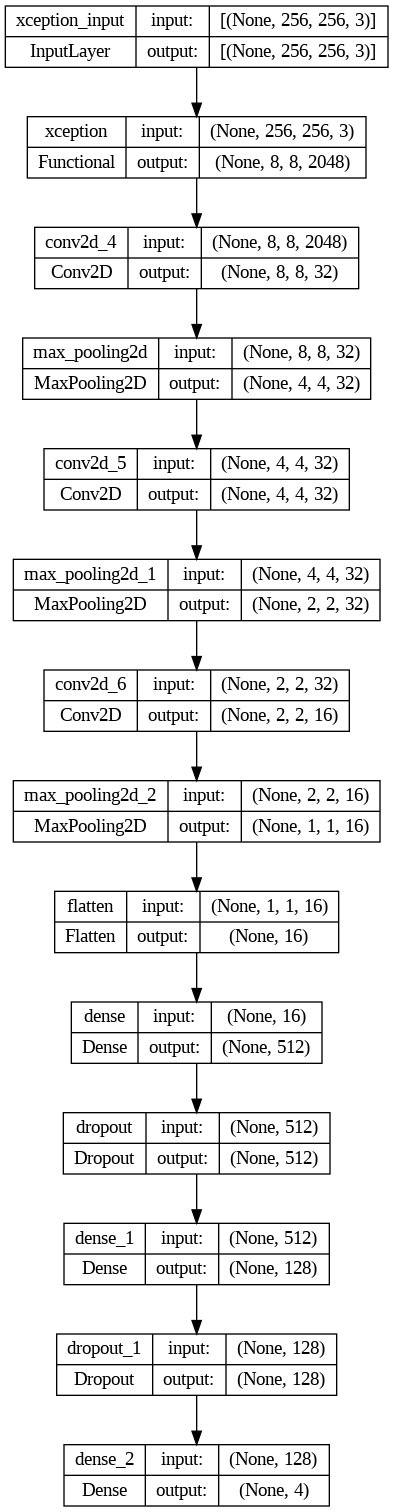

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)


In [ ]:
hist = model.fit(train_gen,
                 epochs=1,
                 validation_data=valid_gen,
                 shuffle= False)

 94/179 [==============>...............] - ETA: 53:40 - loss: 0.7049 - accuracy: 0.7334 - precision: 0.8759 - recall: 0.5821

In [ ]:
hist.history.keys()

In [ ]:
plt.figure(figsize=(14, 14))

plt.subplot(2, 2, 1)
plt.plot(hist.history['loss'], label='loss')
plt.plot(hist.history['val_loss'], label='val_loss')
plt.title('Losses', fontsize=20)
plt.xlabel('epochs')
plt.legend(loc="upper left")

plt.subplot(2, 2, 2)
plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy', fontsize=20)
plt.xlabel('epochs')
plt.legend(loc="upper left")
plt.subplot(2, 2, 3)
plt.plot(hist.history['precision'], label='precision')
plt.plot(hist.history['val_precision'], label='val_precision')
plt.title('Precision', fontsize=20)
plt.xlabel('epochs')
plt.legend(loc="upper left")

plt.subplot(2, 2, 4)
plt.plot(hist.history['recall'], label='recall')
plt.plot(hist.history['val_recall'], label='val_recall')
plt.title('Recall', fontsize=20)
plt.xlabel('epochs')
plt.legend(loc="upper left")

plt.show()

In [ ]:
train_score = model.evaluate(train_gen, verbose= 1)
valid_score = model.evaluate(valid_gen, verbose= 1)
test_score = model.evaluate(test_gen, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

In [ ]:
preds = model.predict_generator(test_gen)
y_pred = np.argmax(preds, axis=1)
print(classification_report(test_gen.classes, y_pred, target_names= classes))

In [ ]:
cm = confusion_matrix(test_gen.classes, y_pred)
labels = classes
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [ ]:
images_test, labels_test = next(iter(test_gen))

for i in range(3):
    plt.imshow(images_test[4])
    plt.axis('off')

    prediction = np.argmax(model.predict(images_test[i][np.newaxis, ...]))
    actual_label = np.argmax(labels_test[i])  # Convert one-hot to index

    print(f"Predicted Label: {classes[prediction]} and Actual Label: {classes[actual_label]}")
    plt.show()

In [ ]:
# Install necessary libraries
!pip install PIL

# Upload the image
from google.colab import files
uploaded = files.upload()  # Upload your image

# Import necessary libraries
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Function to load the image
def load_image(image_path):
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    return image

# Function to preprocess the image
def preprocess_image(image, target_size=(224, 224)):
    image = image.resize(target_size)
    image = np.array(image)
    image = image / 255.0  # Normalization
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    return image

# Function to make predictions
def predict_image(model, image):
    processed_image = preprocess_image(image)
    prediction = model.predict(processed_image)
    return prediction

# Function to display the prediction
def display_prediction(prediction):
    class_labels = ['Class 0', 'Class 1']  # Replace with your actual class labels
    predicted_class = np.argmax(prediction, axis=1)
    print(f'Predicted Class: {class_labels[predicted_class[0]]}')

# Load the image (replace 'your_image.jpg' with the actual image file name)
image_path = 'your_image.jpg'  # Replace with the name of your uploaded image
image = load_image(image_path)

# Preprocess the image and make predictions
prediction = predict_image(logistic_model, image)

# Display the result
display_prediction(prediction)


In [ ]:
model.save('brain_tumor_classifier.h5')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.datasets import load_digits

# Load a sample dataset
digits = load_digits()
X = digits.images
y = digits.target

# For simplicity, let's classify digits 0-4 as class 0 and 5-9 as class 1
y = (y >= 5).astype(int)

# Flatten the images for logistic regression
X = X.reshape((X.shape[0], -1))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Display some sample predictions
for i in range(5):
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
    plt.show()